# Pipeline evaluation LFW benchmark
Authors : Lea Carminati, Anthony Miranda

In this notebook, we evaluate our face recognition pipeline on the **Labeled Faces in the Wild (LFW)** public benchmark. This complements the custom dataset evaluation (`evaluation.ipynb`) by testing the pipeline on a standardised, widely-used dataset with a much larger number of identities and images acquired in uncontrolled conditions.

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
import uuid
import pickle
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

from sklearn.datasets import fetch_lfw_people
from sklearn.manifold import TSNE

from qdrant_client import QdrantClient
from qdrant_client.models import PointStruct, VectorParams, Distance

from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from IPython.display import Markdown, display
import plotly.express as px


import sys
sys.path.append('../fonction/')

from faceDetection import FacesDetects_from_bytes
from faceAlignement2 import align_crop
from faceEmbeddings import get_embedding
from loadModel import load_model
from eval_tools import numpy_to_bytes, run_pipeline, compute_metrics, bootstrap_metric, tar_at_far, plot_embeddings_3d, reduce_3d, fetch_db_vectors, plot_roc


In [5]:
MODEL_PATH     = '../model/blaze_face_short_range.tflite'
COLLECTION_LFW = 'face_lfw'
THRESHOLD      = np.arange(0.0, 1.01, 0.01)
N_IMPOSTORS    = 300
RANDOM_SEED    = 42

arcface_model = load_model("arcface", True)

client = QdrantClient(host="localhost", port=6333)

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.FaceDetectorOptions(base_options=base_options)
detector = vision.FaceDetector.create_from_options(options)

c:\Users\Dell\Desktop\Reconnaissance-Faciale-Projet-Dell-Technologies\.venv\lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


[ModelLoader] ArcFace chargé sur GPU


## Dataset description

The Labeled Faces in the Wild dataset was introduced in 2007 and has become one of the standard benchmarks for face verification and recognition. It contains over 13000 images of 5749 public figures, collected from news articles and web sources.

For this evaluation, we use the scikit-learn interface (`fetch_lfw_people`) and filter to persons with at least 10 photographs, in order to have enough samples for both database registration and genuine evaluation. 

In [6]:
lfw = fetch_lfw_people(min_faces_per_person=10, resize=1.0, color=True)

print(f'Registered people : {len(lfw.target_names)}')
print(f'Total images      : {lfw.images.shape[0]}')
print(f'Image shape       : {lfw.images.shape[1]} x {lfw.images.shape[2]}')
print('\nFirst 10 people:')
for i, name in enumerate(lfw.target_names[:10]):
    print(f'  {name}: {(lfw.target == i).sum()} photos')

Registered people : 158
Total images      : 4324
Image shape       : 125 x 94

First 10 people:
  Abdullah Gul: 19 photos
  Adrien Brody: 12 photos
  Alejandro Toledo: 39 photos
  Alvaro Uribe: 35 photos
  Amelie Mauresmo: 21 photos
  Andre Agassi: 36 photos
  Andy Roddick: 15 photos
  Angelina Jolie: 20 photos
  Ann Veneman: 11 photos
  Anna Kournikova: 12 photos


### Train/test split

For each registered person, images are split chronologically as follows:
- **80%** of each person's photos are stored in the Qdrant vector database as reference embeddings
- **20%** is used as genuine evaluation attempts, never seen during registration

The split is performed **per person** to ensure every identity is represented in both sets. The `max(1, ...)` guard ensures that even persons with very few images always have at least one reference in the database.

Note that this split does not shuffle the images, the natural ordering from the dataset is preserved, which ensures full reproducibility without needing a fixed seed.

In [7]:
person_indices = defaultdict(list)
for idx, label in enumerate(lfw.target):
    person_indices[label].append(idx)

# Split computed ONCE here and reused for both DB population and evaluation,
# so the enrolment set and the evaluation set can never drift apart
# (avoids accidental data leakage of eval images into the database).
db_indices   = {}   # label -> list of indices used to populate the DB
eval_indices = {}   # label -> list of indices used for genuine evaluation

for label, indices in person_indices.items():
    n_db = max(1, int(len(indices) * 0.8))
    db_indices[label]   = indices[:n_db]
    eval_indices[label] = indices[n_db:]

n_db_total   = sum(len(v) for v in db_indices.values())
n_eval_total = sum(len(v) for v in eval_indices.values())
print(f'Images in DB    : {n_db_total}')
print(f'Images for eval : {n_eval_total}')

Images in DB    : 3397
Images for eval : 927


## Database population

Before running the evaluation, we populate a dedicated Qdrant collection (`face_lfw`) with the embeddings of the 80% registration images.

For each registration image, the full pipeline is applied:
1. **Detection** (MediaPipe BlazeFace): detect the face and return a bounding box
2. **Alignment & crop** (`align_crop`): normalise the face region ,align eyes and resize to a fixed dimension
3. **Embedding** (ArcFace): encode the cropped face into a 512-dimensional unit vector

The resulting embedding is stored as a point in Qdrant with a `name` payload field containing the person's identity. Each point is assigned a unique UUID as identifier. Images where no face is detected are silently skipped and not inserted into the database.

The collection uses **cosine similarity** as the distance metric, consistent with the ArcFace embedding space where face similarity is best measured by the angle between vectors.


In [8]:
# Recreate the collection from scratch at every run.
# Rationale: the previous "create only if missing" logic let vectors accumulate
# across re-runs (the collection ended up with ~48k points for ~3.4k images),
# which inflates the database without changing identities. A clean recreate
# keeps the stored count equal to the number of successfully enrolled images.
existing = [c.name for c in client.get_collections().collections]
if COLLECTION_LFW in existing:
    client.delete_collection(collection_name=COLLECTION_LFW)
client.create_collection(
    collection_name=COLLECTION_LFW,
    vectors_config=VectorParams(size=512, distance=Distance.COSINE)
)

# Collect embeddings as we go, to visualise them later without re-reading Qdrant
db_embeddings = []
db_names = []

for label, indices in tqdm(db_indices.items(), desc='Populating DB'):
    for idx in indices:
        img_bytes = numpy_to_bytes(lfw.images[idx])
        boxes, detection_result, image = FacesDetects_from_bytes(img_bytes, 'mediapipe', detector)
        if not detection_result or not detection_result.detections:
            continue
        crops = align_crop(image, detection_result, method="mediapipe")
        if not crops:
            continue
        embedding = get_embedding(crops[0], arcface_model)

        db_embeddings.append(embedding)            # keep for t-SNE
        db_names.append(lfw.target_names[label])   

        client.upsert(
            collection_name=COLLECTION_LFW,
            points=[PointStruct(
                id=str(uuid.uuid4()),
                vector=embedding.tolist(),
                payload={'name': lfw.target_names[label]}
            )]
        )

n_stored = client.count(collection_name=COLLECTION_LFW).count
print(f'Vectors in DB: {n_stored}  (enrolled embeddings: {len(db_embeddings)})')
assert n_stored == len(db_embeddings), "DB count should match enrolled embeddings after a clean recreate"


Populating DB:   0%|          | 0/158 [00:00<?, ?it/s]

Vectors in DB: 3369  (enrolled embeddings: 3369)


## Embedding space visualisation

Once the database is populated, we can look at how the registered identities are organised in
the 512-dimensional ArcFace space. We read the stored vectors back from Qdrant and project them
to 2D with **t-SNE** (cosine metric, matching the search space). To keep the plot readable we
show only the `TOP_K` most represented identities. Well-separated colour clusters indicate that
the embeddings discriminate identities effectively.

In [9]:

TOP_K = 10

vectors = np.array(db_embeddings, dtype=np.float32)
names = np.array(db_names)
print(f"{len(vectors)} embeddings collected, {len(set(names))} identities total")

# keep only the TOP_K most frequent identities
top = [n for n, _ in Counter(names).most_common(TOP_K)]
mask = np.isin(names, top)
X, y = vectors[mask], names[mask]
print(f"Keeping top {TOP_K}: {len(X)} vectors")

# t-SNE down to 3D
emb3d = TSNE(n_components=3, perplexity=min(30, len(X) - 1),
             init="pca", random_state=42, metric="cosine").fit_transform(X)

fig = px.scatter_3d(
    x=emb3d[:, 0], y=emb3d[:, 1], z=emb3d[:, 2],
    color=y, hover_name=y,
    labels={"x": "t-SNE 1", "y": "t-SNE 2", "z": "t-SNE 3", "color": "Person"},
    title=f"LFW registered embeddings (top {TOP_K}) — t-SNE 3D",
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.update_layout(height=650, legend=dict(itemsizing="constant"))
fig.show()

3369 embeddings collected, 158 identities total
Keeping top 10: 1152 vectors


## Pipeline execution

We now run the full recognition pipeline on two sets of images:

- **Genuine attempts**: the 20% evaluation split of registered persons, the system should correctly identify them
- **Impostor attempts**: 300 images sampled at random (seed=42) from persons **not present** in the registered set, the system should reject them

For each image, the same four-step pipeline is applied (detection, alignment,  embedding, vector search). The vector search queries the `face_lfw` collection and returns the closest stored identity with its cosine similarity score. Images where no face is detected are counted as failures and excluded from all subsequent metric calculations.

Each processed image produces a result dictionary with the following fields:

| Field | Description |
|---|---|
| `label_true` | Ground truth identity (or `'unknown'` for impostors) |
| `predicted_name` | Identity returned by Qdrant |
| `score` | Cosine similarity score |
| `is_genuine` | `True` for registered persons, `False` for impostors |

Note the **imbalance** between genuine and impostor attempts: genuine attempts depend on the 20% split across all persons, while impostors are fixed at 300. This reflects a realistic open-set scenario where impostors are encountered less frequently than registered users.

In [10]:
results_lfw = []
detection_failures = 0
arcface_model = load_model("arcface", True)

# genuine attempts (reuse the eval split computed above)
for label, indices in tqdm(eval_indices.items(), desc='Genuine'):
    for idx in indices:
        img_bytes = numpy_to_bytes(lfw.images[idx])
        result = run_pipeline(
            img_bytes, detector, client, COLLECTION_LFW,
            label_true=lfw.target_names[label], is_genuine=True,
            align_crop_fn=align_crop, get_embedding_fn=get_embedding,
            FacesDetects_fn=FacesDetects_from_bytes, arcface_model=arcface_model
        )
        if result is None or result.get("status") != "ok":
            detection_failures += 1
        else:
            results_lfw.append(result)

# impostor attempts: people NOT registered in the DB
lfw_all = fetch_lfw_people(min_faces_per_person=1, resize=1.0, color=True)
registered_names = set(lfw.target_names)
impostor_pool = [i for i, label in enumerate(lfw_all.target)
                 if lfw_all.target_names[label] not in registered_names]

random.seed(RANDOM_SEED)
impostor_sample = random.sample(impostor_pool, N_IMPOSTORS)

for idx in tqdm(impostor_sample, desc='Impostors'):
    img_bytes = numpy_to_bytes(lfw_all.images[idx])
    result = run_pipeline(
        img_bytes, detector, client, COLLECTION_LFW,
        label_true='unknown', is_genuine=False,
        align_crop_fn=align_crop, get_embedding_fn=get_embedding,
        FacesDetects_fn=FacesDetects_from_bytes, arcface_model=arcface_model
    )
    if result is None or result.get("status") != "ok":
        detection_failures += 1
    else:
        results_lfw.append(result)

genuine_lfw  = [r for r in results_lfw if r['is_genuine']]
impostor_lfw = [r for r in results_lfw if not r['is_genuine']]

print(f'Genuine   : {len(genuine_lfw)}')
print(f'Impostors : {len(impostor_lfw)}')
print(f'Failures  : {detection_failures}')

[ModelLoader] ArcFace chargé sur GPU


c:\Users\Dell\Desktop\Reconnaissance-Faciale-Projet-Dell-Technologies\.venv\lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Genuine:   0%|          | 0/158 [00:00<?, ?it/s]

Impostors:   0%|          | 0/300 [00:00<?, ?it/s]

Genuine   : 917
Impostors : 298
Failures  : 12


Images discarded before matching (12 in total) are excluded from the TAR, FAR, FRR and EER calculations. They fall into two categories: **no detection**, MediaPipe BlazeFace found no face at all, typically due to extreme pose, strong blur, or partial occlusion of key landmarks (eyes, nose) , and **rejected alignment** a face was detected but discarded by the frontality gate (`_YAW_MAX`), which filters strong profiles whose alignment to the ArcFace template would be unreliable.

## Score distribution

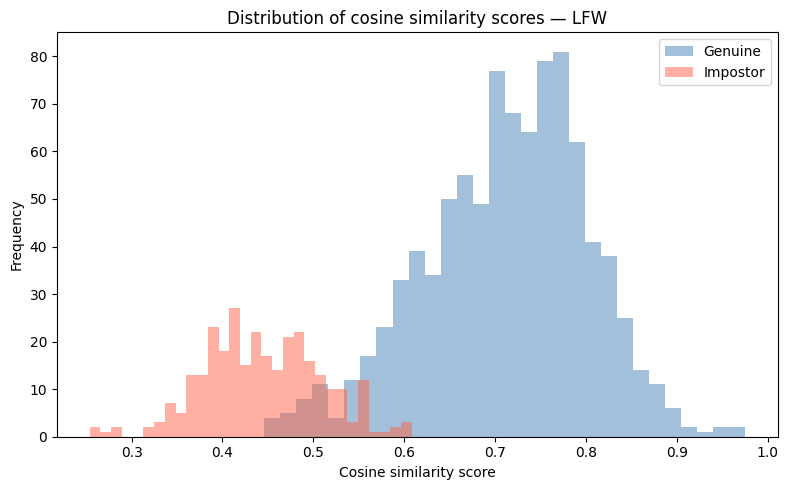

In [11]:
plt.figure(figsize=(8, 5))
plt.hist([r['score'] for r in genuine_lfw],  bins=30, alpha=0.5, label='Genuine',  color='steelblue')
plt.hist([r['score'] for r in impostor_lfw], bins=30, alpha=0.5, label='Impostor', color='tomato')
plt.xlabel('Cosine similarity score')
plt.ylabel('Frequency')
plt.title('Distribution of cosine similarity scores — LFW')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
g = np.array([r["score"] for r in genuine_lfw])
i = np.array([r["score"] for r in impostor_lfw])

display(Markdown(f"""
The histogram shows cosine similarity scores for **genuine** ({len(g)} attempts,
mean {g.mean():.2f}) and **impostor** ({len(i)} attempts, mean {i.mean():.2f}) comparisons.

The genuine scores form a single, well-defined cluster centred around **{np.median(g):.2f}**,
while the impostor scores sit clearly lower (around **{np.median(i):.2f}**). The two
populations are largely separated, with only a modest overlap region, this clean separation
is what allows a threshold to distinguish genuine from impostor reliably, and is reflected in
the low EER reported below.
"""))


The histogram shows cosine similarity scores for **genuine** (917 attempts,
mean 0.71) and **impostor** (298 attempts, mean 0.44) comparisons.

The genuine scores form a single, well-defined cluster centred around **0.72**,
while the impostor scores sit clearly lower (around **0.44**). The two
populations are largely separated, with only a modest overlap region, this clean separation
is what allows a threshold to distinguish genuine from impostor reliably, and is reflected in
the low EER reported below.


## Biometric evaluation metrics

We use the same standard biometric metrics as in the custom dataset evaluation, defined in the **ISO/IEC 19795** norm:

- **TAR** (True Acceptance Rate)

- **FAR** (False Acceptance Rate)

- **FRR** (False Reject Rate)

- **EER** (Equal Error Rate)

In [14]:
m = compute_metrics(genuine_lfw, impostor_lfw, THRESHOLD)
b_eer = bootstrap_metric(genuine_lfw, impostor_lfw, THRESHOLD, "eer_value", n_boot=1000)
b_auc = bootstrap_metric(genuine_lfw, impostor_lfw, THRESHOLD, "auc",       n_boot=1000)

print(f'EER           : {m["eer_value"]*100:.2f}%   95% CI [{b_eer["ci_low"]*100:.2f}%, {b_eer["ci_high"]*100:.2f}%]')
print(f'EER threshold : {m["eer_threshold"]:.2f}')
print(f'TAR at EER    : {m["tar"][m["eer_idx"]]*100:.2f}%')
print(f'AUC (ROC)     : {m["auc"]:.4f}   95% CI [{b_auc["ci_low"]:.3f}, {b_auc["ci_high"]:.3f}]')

EER           : 5.58%   95% CI [3.75%, 6.96%]
EER threshold : 0.55
TAR at EER    : 94.87%
AUC (ROC)     : 0.9786   95% CI [0.970, 0.986]


In [15]:

display(Markdown(f"""
The system achieves an **EER of {m['eer_value']*100:.2f}%** at a threshold of
**{m['eer_threshold']:.2f}**, with a **TAR of {m['tar'][m['eer_idx']]*100:.1f}%** at this
operating point and an **AUC of {m['auc']:.3f}**. The bootstrap 95% confidence intervals
([{b_eer['ci_low']*100:.1f}%, {b_eer['ci_high']*100:.1f}%] for the EER) are narrow, a direct
consequence of the large evaluation sample ({len(genuine_lfw)} genuine, {len(impostor_lfw)}
impostor attempts).

These figures confirm that on standard "in the wild" photographs the pipeline performs
reliably, validating the correctness of the full processing chain (detection, alignment,
embedding extraction, vector search). A detailed comparison with the custom dataset is
provided separately in `comparaison.ipynb`.
"""))


The system achieves an **EER of 5.58%** at a threshold of
**0.55**, with a **TAR of 94.9%** at this
operating point and an **AUC of 0.979**. The bootstrap 95% confidence intervals
([3.7%, 7.0%] for the EER) are narrow, a direct
consequence of the large evaluation sample (917 genuine, 298
impostor attempts).

These figures confirm that on standard "in the wild" photographs the pipeline performs
reliably, validating the correctness of the full processing chain (detection, alignment,
embedding extraction, vector search). A detailed comparison with the custom dataset is
provided separately in `comparaison.ipynb`.


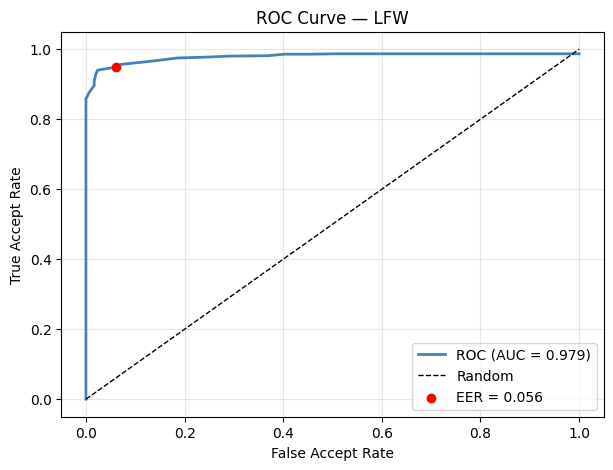

In [16]:
plot_roc(m, "ROC Curve — LFW")

In [17]:
display(Markdown(f"""
The ROC curve rises steeply toward the top-left corner (high TAR at low FAR), confirming the
strong discriminative capacity of the system on LFW (**AUC = {m['auc']:.3f}**). The red dot
marks the EER operating point, at FAR = FRR ≈ {m['eer_value']*100:.1f}%. A random classifier
would follow the diagonal (AUC = 0.5); here the curve sits well above it.
"""))


The ROC curve rises steeply toward the top-left corner (high TAR at low FAR), confirming the
strong discriminative capacity of the system on LFW (**AUC = 0.979**). The red dot
marks the EER operating point, at FAR = FRR ≈ 5.6%. A random classifier
would follow the diagonal (AUC = 0.5); here the curve sits well above it.


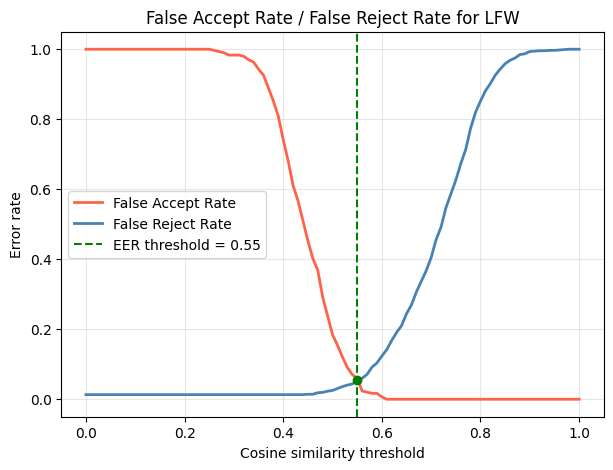

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(THRESHOLD, m['far'], color='tomato',    lw=2, label='False Accept Rate')
plt.plot(THRESHOLD, m['frr'], color='steelblue', lw=2, label='False Reject Rate')
plt.axvline(m['eer_threshold'], color='green', linestyle='--', lw=1.5,
            label=f'EER threshold = {m["eer_threshold"]:.2f}')
plt.scatter(m['eer_threshold'], m['eer_value'], color='green', zorder=5)
plt.xlabel('Cosine similarity threshold')
plt.ylabel('Error rate')
plt.title('False Accept Rate / False Reject Rate for LFW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
display(Markdown(f"""
The FAR/FRR curves show the expected trade-off: as the threshold increases, the False Accept
Rate falls (fewer impostors accepted) while the False Reject Rate rises (more genuine users
rejected). They intersect at **threshold = {m['eer_threshold']:.2f}**, the EER operating point,
where both error rates are ≈ {m['eer_value']*100:.1f}%. The steep transition of both curves
around this threshold reflects the clear separation between the genuine and impostor score
distributions seen in the histogram above.
"""))


The FAR/FRR curves show the expected trade-off: as the threshold increases, the False Accept
Rate falls (fewer impostors accepted) while the False Reject Rate rises (more genuine users
rejected). They intersect at **threshold = 0.55**, the EER operating point,
where both error rates are ≈ 5.6%. The steep transition of both curves
around this threshold reflects the clear separation between the genuine and impostor score
distributions seen in the histogram above.


### Operating points: TAR at fixed FAR budgets

Beyond the balanced EER point, we report the operating points a real deployment would use: the best achievable TAR under a fixed FAR budget. With ~300 impostor attempts the FAR granularity is ≈ 0.3%, so budgets down to 1% are meaningful (unlike on the custom dataset, where 16 impostors made this analysis degenerate).

In [20]:
for target in (0.10, 0.01, 0.001):
    res = tar_at_far(m, THRESHOLD, target)
    if res is None:
        print(f"FAR <= {target*100:>4.1f}%  : not reachable with this grid")
    else:
        print(f"TAR @ FAR<={target*100:>4.1f}%  : {res['tar']*100:5.1f}%  "
              f"(threshold {res['threshold']:.2f}, actual FAR {res['far']*100:.2f}%)")


TAR @ FAR<=10.0%  :  96.0%  (threshold 0.53, actual FAR 9.06%)
TAR @ FAR<= 1.0%  :  87.7%  (threshold 0.60, actual FAR 0.67%)
TAR @ FAR<= 0.1%  :  85.8%  (threshold 0.61, actual FAR 0.00%)


Even under a strict **FAR ≤ 1%** budget the pipeline keeps a high TAR (≈ 88%, threshold ≈ 0.60, as also reported in `comparaison.ipynb`). This is the kind of secure-and-usable operating point that the custom stress-test could not provide, and it quantifies how much headroom the matcher has when acquisition conditions are reasonable.

## Export results

The per-attempt results are serialised to `results_lfw.pkl` for the side-by-side analysis in `comparaison.ipynb`, which recomputes all metrics on both datasets with the same code path.

In [21]:
with open('results_lfw.pkl', 'wb') as f:
    pickle.dump({'genuine': genuine_lfw, 'impostor': impostor_lfw}, f)

print(f"Saved results_lfw.pkl  ({len(genuine_lfw)} genuine, {len(impostor_lfw)} impostor)")

Saved results_lfw.pkl  (917 genuine, 298 impostor)


## Conclusion

On LFW the pipeline reaches an **EER of 5.58%** (95% CI [3.75%, 6.96%]) with an AUC
of 0.979 and a TAR of ≈ 88% at FAR ≤ 1%. The narrow confidence intervals follow from the large sample (917 genuine, 298 impostor attempts). These figures confirm that the full processing chain — detection, alignment, embedding extraction, vector search — is implemented correctly, and they provide the reference against which the degraded performance on the custom stress-test dataset is interpreted in `comparaison.ipynb`.